In [1]:
# data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


# models 
from sklearn.model_selection import train_test_split    
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import HistGradientBoostingClassifier 
from sklearn.svm import SVC

# evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# file handling
from pathlib import Path

In [2]:
# load the dataset 
data_path = Path("../dataset/archive/creditcard_2023.csv")

In [3]:
# load the dataset 
df = pd.read_csv(data_path)
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [4]:
# get the dataset count 
df.shape

(568630, 31)

In [5]:
# get the dataset information and statistics 
df.info()
df.describe() 

<class 'pandas.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     568630 non-nu

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,568630.000000,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,5.686300e+05,5.686300e+05,568630.000000,5.686300e+05,568630.000000,...,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,5.686300e+05,5.686300e+05,568630.000000,568630.0
mean,284314.500000,-5.118237e-17,-5.118237e-17,1.023647e-16,0.000000,2.559118e-17,2.559118e-17,0.000000,1.279559e-17,0.000000,...,1.279559e-17,3.198898e-18,5.598072e-18,-2.559118e-17,-4.478457e-17,0.000000,-2.559118e-17,3.198898e-17,12041.957635,0.5
std,164149.486122,1.000001e+00,1.000001e+00,1.000001e+00,1.000001,1.000001e+00,1.000001e+00,1.000001,1.000001e+00,1.000001,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001,1.000001e+00,1.000001e+00,6919.644449,0.5
min,0.000000,-3.495584e+00,-4.996657e+01,-3.183760e+00,-4.951222,-9.952786e+00,-2.111111e+01,-4.351839,-1.075634e+01,-3.751919,...,-1.938252e+01,-7.734798e+00,-3.029545e+01,-4.067968e+00,-1.361263e+01,-8.226969,-1.049863e+01,-3.903524e+01,50.010000,0.0
25%,142157.250000,-5.652859e-01,-4.866777e-01,-6.492987e-01,-0.656020,-2.934955e-01,-4.458712e-01,-0.283533,-1.922572e-01,-0.568745,...,-1.664408e-01,-4.904892e-01,-2.376289e-01,-6.515801e-01,-5.541485e-01,-0.631895,-3.049607e-01,-2.318783e-01,6054.892500,0.0
50%,284314.500000,-9.363846e-02,-1.358939e-01,3.528579e-04,-0.073762,8.108788e-02,7.871758e-02,0.233366,-1.145242e-01,0.092526,...,-3.743065e-02,-2.732881e-02,-5.968903e-02,1.590123e-02,-8.193162e-03,-0.011892,-1.729111e-01,-1.392973e-02,12030.150000,0.5
75%,426471.750000,8.326582e-01,3.435552e-01,6.285380e-01,0.707005,4.397368e-01,4.977881e-01,0.525955,4.729905e-02,0.559262,...,1.479787e-01,4.638817e-01,1.557153e-01,7.007374e-01,5.500147e-01,0.672888,3.340230e-01,4.095903e-01,18036.330000,1.0
max,568629.000000,2.229046e+00,4.361865e+00,1.412583e+01,3.201536,4.271689e+01,2.616840e+01,217.873038,5.958040e+00,20.270062,...,8.087080e+00,1.263251e+01,3.170763e+01,1.296564e+01,1.462151e+01,5.623285,1.132311e+02,7.725594e+01,24039.930000,1.0


In [6]:
# list all of the columns in the dataset
df.columns

Index(['id', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [7]:
# check for missing values and null, duplicates and so on 
print(df.isnull().sum())
print(df.duplicated().sum())

id        0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
0


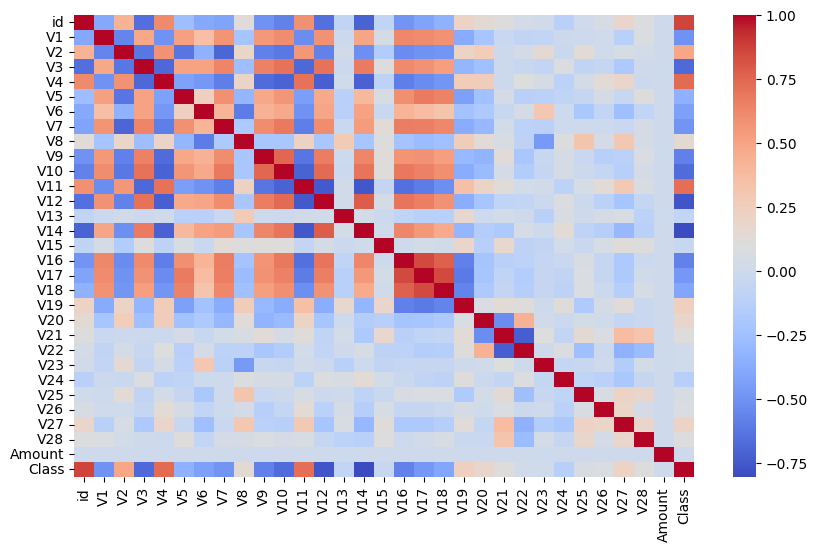

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.show()


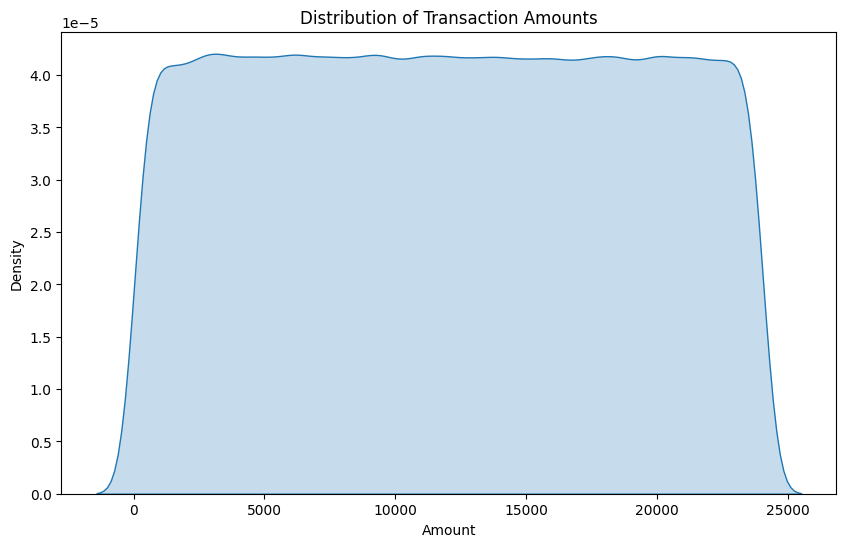

In [9]:
# using kde plot to visualize the distribution of the features
plt.figure(figsize=(10, 6))
sns.kdeplot(df["Amount"], fill=True)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.show()

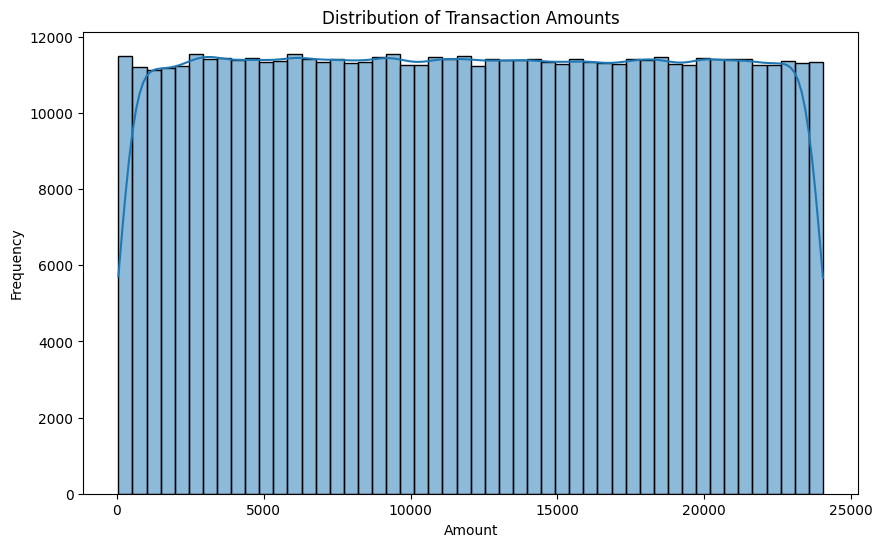

In [10]:
# histogram to visualize the distribution of the features
plt.figure(figsize=(10, 6))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

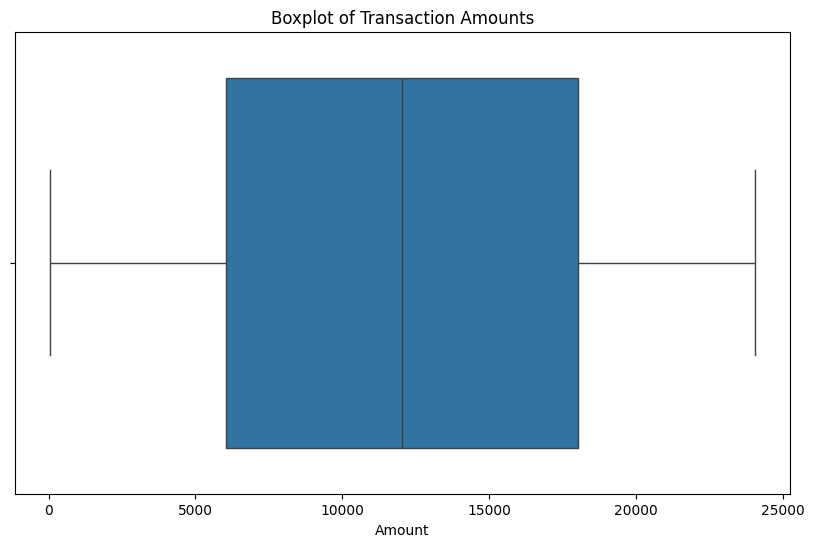

In [11]:
# get the outliers in the dataset using boxplot 
plt.figure(figsize=(10, 6))
sns.boxplot(x=df["Amount"])
plt.title("Boxplot of Transaction Amounts")
plt.xlabel("Amount")
plt.show()

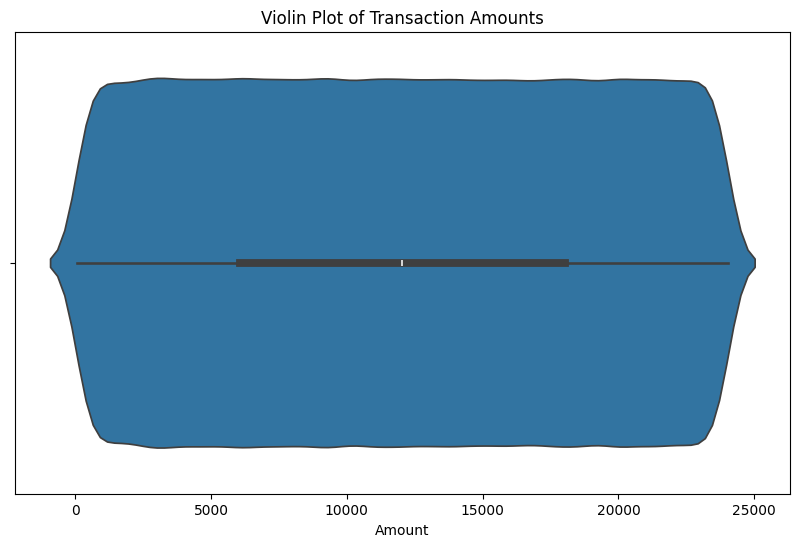

In [12]:
# tree map to visualize the distribution of the features
plt.figure(figsize=(10, 6))
sns.violinplot(x=df["Amount"])
plt.title("Violin Plot of Transaction Amounts")
plt.xlabel("Amount")
plt.show()

In [13]:
# normalize the dataset NOTE: becuase the dataset has different scales, we need to normalize it before training the model. We can use StandardScaler for this purpose.
# scaler = StandardScaler()
# scaled_features = scaler.fit_transform(df.drop("Class", axis=1))
# X = pd.DataFrame(scaled_features, columns=df.columns[:-1])
# y = df["Class"]

# print(X.head())

In [14]:
# split the dataset into features and target using 80-20 split
X_train = df.drop("Class", axis=1)
y_train = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42, )


In [ ]:
# train svm model 
svm_model = SVC(kernel="rbf", random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))
print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("SVM Accuracy Score:", accuracy_score(y_test, y_pred_svm))

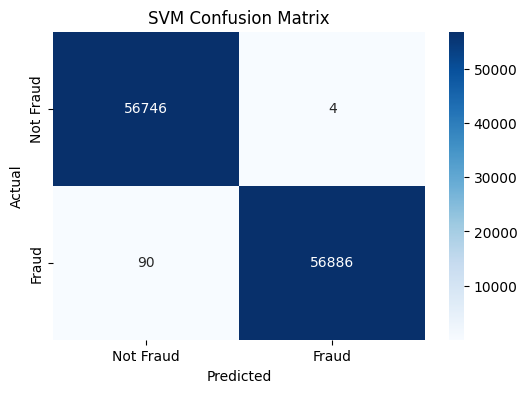

In [ ]:
# plot the confusion matrix for the svm model
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Logistic Regression
logistic_scaler = StandardScaler()
X_train_scaled = logistic_scaler.fit_transform(X_train)
X_test_scaled = logistic_scaler.transform(X_test)

logistic_model = LogisticRegression(random_state=42, max_iter=1000, solver="lbfgs")
logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logistic))
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))
print("Logistic Regression Accuracy Score:", accuracy_score(y_test, y_pred_logistic))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

Logistic Regression Confusion Matrix:
[[56680    70]
 [  120 56856]]
Logistic Regression Accuracy Score: 0.9983293178340925


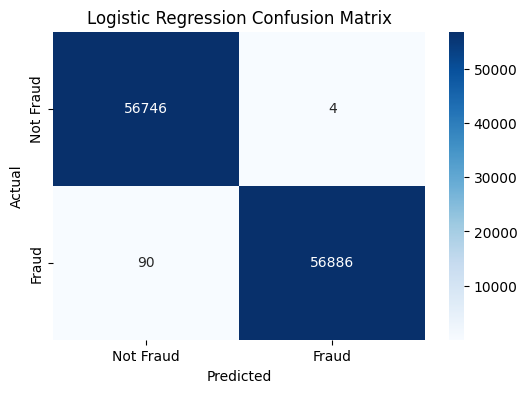

In [ ]:
# plot the confusion matrix for the logistic regression model
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# K-nearest neighbors (KNN) with k=4
knn_model = KNeighborsClassifier(n_neighbors=4)
knn_model.fit(X_train, y_train) 
y_pred_knn = knn_model.predict(X_test)
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))
print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("KNN Accuracy Score:", accuracy_score(y_test, y_pred_knn))

KNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

KNN Confusion Matrix:
[[56745     5]
 [   98 56878]]
KNN Accuracy Score: 0.9990943144047975


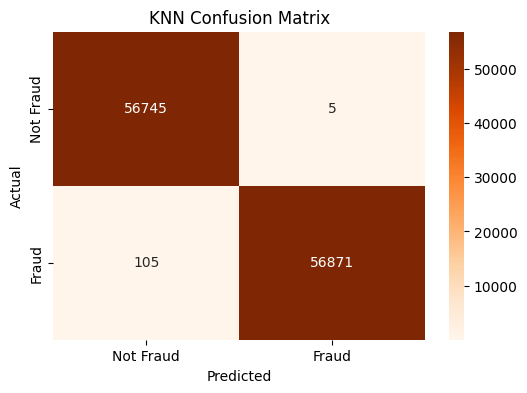

In [ ]:
# plot the confusion matrix for the knn model
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",    
    cmap="Oranges",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
)
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# train Gaussian Naive Bayes model
gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)
y_pred_gnb = gnb_model.predict(X_test)
print("Gaussian Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_gnb))
print("Gaussian Naive Bayes Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gnb))
print("Gaussian Naive Bayes Accuracy Score:", accuracy_score(y_test, y_pred_gnb))

Gaussian Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     56750
           1       1.00      0.99      0.99     56976

    accuracy                           0.99    113726
   macro avg       0.99      0.99      0.99    113726
weighted avg       0.99      0.99      0.99    113726

Gaussian Naive Bayes Confusion Matrix:
[[56750     0]
 [  625 56351]]
Gaussian Naive Bayes Accuracy Score: 0.9945043349805673


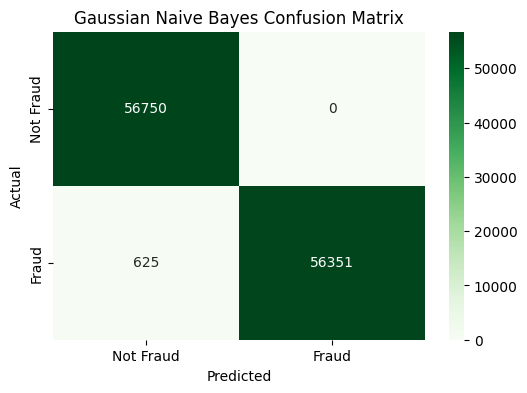

In [ ]:
# plot the Gaussian Naive Bayes confusion matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_gnb)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
)
plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# train HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(random_state=42)
hgb_model.fit(X_train, y_train)
y_pred_hgb = hgb_model.predict(X_test)
print("HistGradientBoostingClassifier Classification Report:")
print(classification_report(y_test, y_pred_hgb))
print("HistGradientBoostingClassifier Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_hgb))
print("HistGradientBoostingClassifier Accuracy Score:", accuracy_score(y_test, y_pred_hgb))



HistGradientBoostingClassifier Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

HistGradientBoostingClassifier Confusion Matrix:
[[56740    10]
 [   14 56962]]
HistGradientBoostingClassifier Accuracy Score: 0.9997889664632538


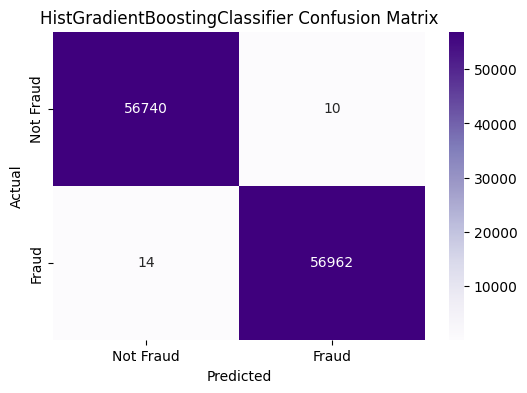

In [ ]:
# plot the confusion matrix for the HistGradientBoostingClassifier xboost model
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_hgb)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
)
plt.title("HistGradientBoostingClassifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()  

In [ ]:
# train decision tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))
print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("Decision Tree Accuracy Score:", accuracy_score(y_test, y_pred_dt))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

Decision Tree Confusion Matrix:
[[56722    28]
 [   20 56956]]
Decision Tree Accuracy Score: 0.9995779329265075


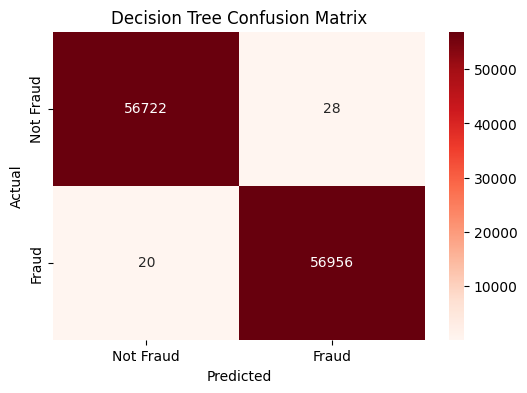

In [ ]:
# plot the confusion matrix for the decision tree model
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",        
    cmap="Reds",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()  